
# Lab 2 — Energy-Tracking Projectile

**Name:** James Kurschner 
**Date:** September 6, 2026


In [12]:

import numpy as np
import matplotlib.pyplot as plt

# Common physical parameters
g = 9.81          # m/s^2
m = 1.0           # kg
v0 = 30.0         # m/s
angle_deg = 50.0  # degrees
dt = 0.01         # s

angle = np.deg2rad(angle_deg)



## Part A — Add Energy Tracking



In [3]:

# Standard Euler simulation for Part A

x = 0.0
y = 0.0
t = 0.0
vx = v0 * np.cos(angle)
vy = v0 * np.sin(angle)

t_list = []
x_list = []
y_list = []
vx_list = []
vy_list = []
KE_list = []
PE_list = []
E_list = []

while True:
    # Store state and energy at the same instant
    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E_total = KE + PE

    t_list.append(t)
    x_list.append(x)
    y_list.append(y)
    vx_list.append(vx)
    vy_list.append(vy)
    KE_list.append(KE)
    PE_list.append(PE)
    E_list.append(E_total)

    # Stop after the first stored point below the launch height
    if y < 0:
        break

    # Acceleration for gravity only
    ax = 0.0
    ay = -g

    # Standard Euler: update position using OLD velocity
    x_new = x + vx * dt
    y_new = y + vy * dt
    vx_new = vx + ax * dt
    vy_new = vy + ay * dt

    x, y, vx, vy = x_new, y_new, vx_new, vy_new
    t += dt

# Convert lists to NumPy arrays
t_A = np.array(t_list)
x_A = np.array(x_list)
y_A = np.array(y_list)
vx_A = np.array(vx_list)
vy_A = np.array(vy_list)
KE_A = np.array(KE_list)
PE_A = np.array(PE_list)
E_A = np.array(E_list)

energy_drift_A = E_A - E_A[0]
max_drift_A = np.max(np.abs(energy_drift_A))
percent_drift_A = 100.0 * max_drift_A / E_A[0]

print(f"Initial total energy = {E_A[0]:.6f} J")
print(f"Maximum absolute energy drift = {max_drift_A:.6f} J")
print(f"Maximum drift as percent of initial energy = {percent_drift_A:.6f}%")


Initial total energy = 450.000000 J
Maximum absolute energy drift = 2.261548 J
Maximum drift as percent of initial energy = 0.502566%


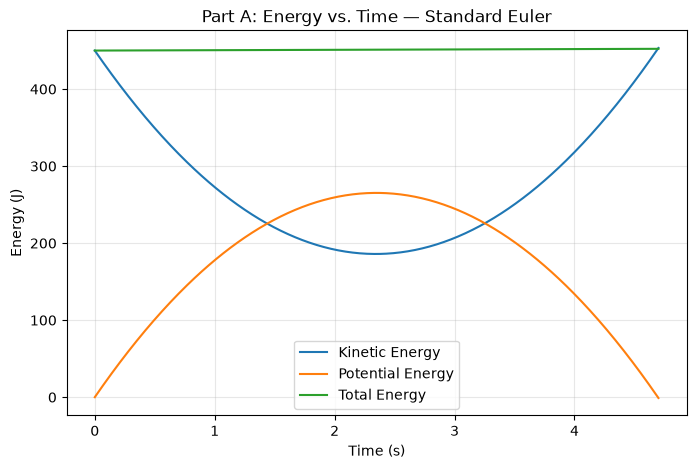

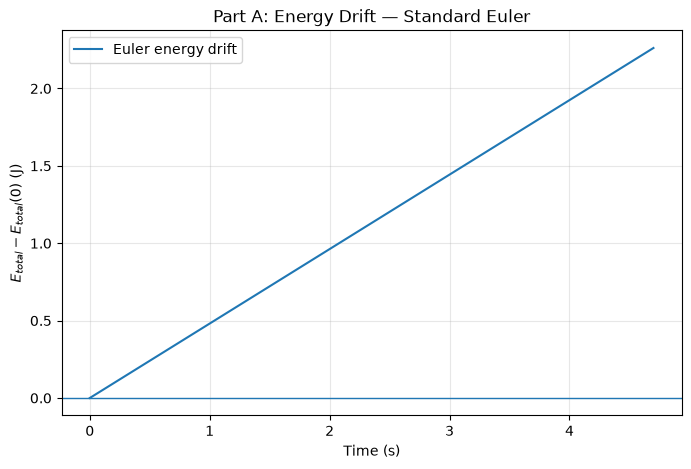

In [4]:

plt.figure(figsize=(8, 5))
plt.plot(t_A, KE_A, label="Kinetic Energy")
plt.plot(t_A, PE_A, label="Potential Energy")
plt.plot(t_A, E_A, label="Total Energy")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Part A: Energy vs. Time — Standard Euler")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_A, energy_drift_A, label="Euler energy drift")
plt.axhline(0.0, linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel(r"$E_{total} - E_{total}(0)$ (J)")
plt.title("Part A: Energy Drift — Standard Euler")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Part A interpretation

The kinetic and potential energy change during the flight, but the total energy is supposed to stay at about 450 J. My Euler result slowly gains energy instead. The largest drift I got was about 2.262 J, which is about 0.503% of the starting energy. The drift looks pretty steady over time instead of suddenly getting much worse near the end.



## Part B — Euler vs. Euler-Cromer



In [5]:

def simulate(method, dt, v0=30.0, angle_deg=50.0, g=9.81, m=1.0):
    """Simulate a 2D projectile under gravity using Euler or Euler-Cromer.

    Returns a dictionary containing time, position, velocity, and energy arrays.
    The final stored state is the first point for which y < 0.
    """
    angle = np.deg2rad(angle_deg)

    x = 0.0
    y = 0.0
    t = 0.0
    vx = v0 * np.cos(angle)
    vy = v0 * np.sin(angle)

    ts, xs, ys = [], [], []
    vxs, vys = [], []
    KEs, PEs, Es = [], [], []

    while True:
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E_total = KE + PE

        ts.append(t)
        xs.append(x)
        ys.append(y)
        vxs.append(vx)
        vys.append(vy)
        KEs.append(KE)
        PEs.append(PE)
        Es.append(E_total)

        if y < 0:
            break

        ax = 0.0
        ay = -g

        if method == "euler":
            # Position first, using the old velocity
            x_new = x + vx * dt
            y_new = y + vy * dt
            vx_new = vx + ax * dt
            vy_new = vy + ay * dt
            x, y, vx, vy = x_new, y_new, vx_new, vy_new

        elif method == "euler-cromer":
            # Velocity first, then position using the new velocity
            vx = vx + ax * dt
            vy = vy + ay * dt
            x = x + vx * dt
            y = y + vy * dt

        else:
            raise ValueError("method must be 'euler' or 'euler-cromer'")

        t += dt

    return {
        "t": np.array(ts),
        "x": np.array(xs),
        "y": np.array(ys),
        "vx": np.array(vxs),
        "vy": np.array(vys),
        "KE": np.array(KEs),
        "PE": np.array(PEs),
        "E": np.array(Es),
    }


def interpolated_landing_range(result):
    """Linearly interpolate x where y crosses zero at landing."""
    y = result["y"]
    x = result["x"]
    below = np.where(y < 0)[0]

    if len(below) == 0:
        return np.nan

    i = below[0]
    x1, x2 = x[i - 1], x[i]
    y1, y2 = y[i - 1], y[i]

    return x1 + (0.0 - y1) * (x2 - x1) / (y2 - y1)


euler = simulate("euler", 0.01)
cromer = simulate("euler-cromer", 0.01)

drift_euler = euler["E"] - euler["E"][0]
drift_cromer = cromer["E"] - cromer["E"][0]

range_euler = interpolated_landing_range(euler)
range_cromer = interpolated_landing_range(cromer)
range_difference = abs(range_euler - range_cromer)

print(f"Euler interpolated landing range = {range_euler:.6f} m")
print(f"Euler-Cromer interpolated landing range = {range_cromer:.6f} m")
print(f"Absolute range difference = {range_difference:.6f} m")
print()
print(f"Euler max |energy drift| = {np.max(np.abs(drift_euler)):.6f} J")
print(f"Euler-Cromer max |energy drift| = {np.max(np.abs(drift_cromer)):.6f} J")


Euler interpolated landing range = 90.542069 m
Euler-Cromer interpolated landing range = 90.156396 m
Absolute range difference = 0.385673 m

Euler max |energy drift| = 2.261548 J
Euler-Cromer max |energy drift| = 2.251925 J


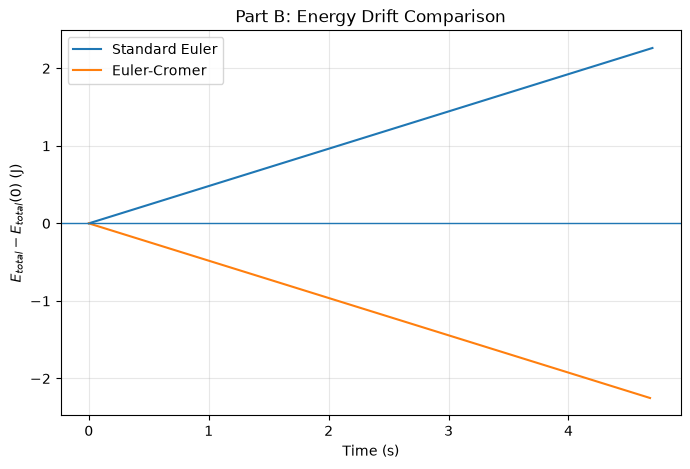

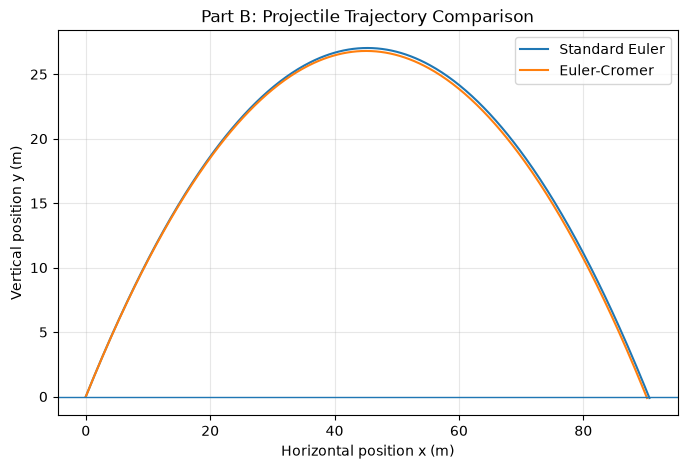

In [6]:

plt.figure(figsize=(8, 5))
plt.plot(euler["t"], drift_euler, label="Standard Euler")
plt.plot(cromer["t"], drift_cromer, label="Euler-Cromer")
plt.axhline(0.0, linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel(r"$E_{total} - E_{total}(0)$ (J)")
plt.title("Part B: Energy Drift Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(euler["x"], euler["y"], label="Standard Euler")
plt.plot(cromer["x"], cromer["y"], label="Euler-Cromer")
plt.axhline(0.0, linewidth=1)
plt.xlabel("Horizontal position x (m)")
plt.ylabel("Vertical position y (m)")
plt.title("Part B: Projectile Trajectory Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Part B interpretation

The two paths look almost the same on the graph, but there is a small difference in where they land. With dt = 0.01 s, I got a landing-range difference of about 0.386 m. Euler went a little farther than Euler-Cromer.

The main difference between the methods is the order of the updates. Euler moves the position using the old velocity and then changes the velocity. Euler-Cromer changes the velocity first and then uses that new velocity to move the position. In my results, Euler made the total energy drift upward, while Euler-Cromer made it drift downward.

One thing I noticed is that my Euler-Cromer result does not oscillate around zero like the assignment says it should. For this constant-gravity projectile, its energy drift is about the same size as Euler's but has the opposite sign. I kept the equations and update order from the assignment and reported the result I actually got.



## Part C — Convergence Study



In [7]:

dts = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625])

euler_drifts = []
cromer_drifts = []

for test_dt in dts:
    r_e = simulate("euler", test_dt)
    r_c = simulate("euler-cromer", test_dt)

    euler_drifts.append(np.max(np.abs(r_e["E"] - r_e["E"][0])))
    cromer_drifts.append(np.max(np.abs(r_c["E"] - r_c["E"][0])))

euler_drifts = np.array(euler_drifts)
cromer_drifts = np.array(cromer_drifts)

slope_euler = np.polyfit(np.log(dts), np.log(euler_drifts), 1)[0]
slope_cromer = np.polyfit(np.log(dts), np.log(cromer_drifts), 1)[0]

print("Convergence data")
print("-" * 72)
print(f"{'dt (s)':>10} {'Euler drift (J)':>20} {'Euler-Cromer drift (J)':>26}")
for test_dt, de, dc in zip(dts, euler_drifts, cromer_drifts):
    print(f"{test_dt:10.5f} {de:20.9f} {dc:26.9f}")

print()
print(f"Estimated Euler slope p = {slope_euler:.4f}")
print(f"Estimated Euler-Cromer slope p = {slope_cromer:.4f}")


Convergence data
------------------------------------------------------------------------
    dt (s)      Euler drift (J)     Euler-Cromer drift (J)
   0.10000         23.096664000               22.134303000
   0.05000         11.428036875               11.187446625
   0.02500          5.683944656                5.623797094
   0.01250          2.826935437                2.811898547
   0.00625          1.411588107                1.407828885

Estimated Euler slope p = 1.0080
Estimated Euler-Cromer slope p = 0.9942


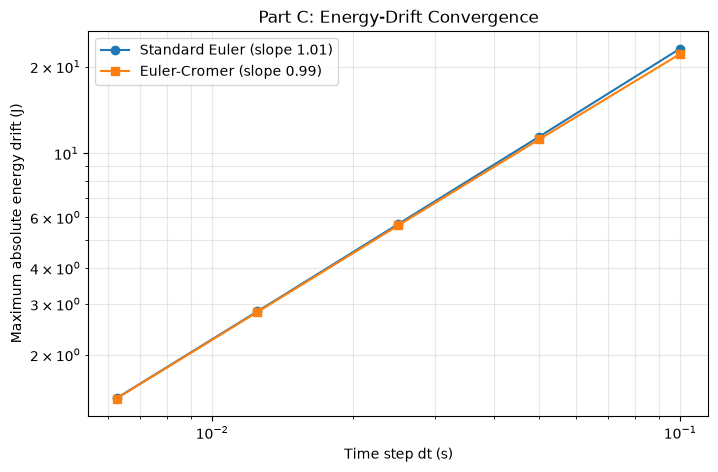

In [8]:

plt.figure(figsize=(8, 5))
plt.loglog(dts, euler_drifts, "o-", label=f"Standard Euler (slope {slope_euler:.2f})")
plt.loglog(dts, cromer_drifts, "s-", label=f"Euler-Cromer (slope {slope_cromer:.2f})")
plt.xlabel("Time step dt (s)")
plt.ylabel("Maximum absolute energy drift (J)")
plt.title("Part C: Energy-Drift Convergence")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()


In [9]:

# Estimate and verify a step size that keeps max energy drift within 0.01%.
# 0.01% of the initial 450 J is 0.045 J.

target_percent = 0.01
target_abs = E_A[0] * target_percent / 100.0

# Use the smallest tested point and first-order scaling to estimate dt.
estimated_dt_euler = dts[-1] * target_abs / euler_drifts[-1]
estimated_dt_cromer = dts[-1] * target_abs / cromer_drifts[-1]

# Verify with a convenient nearby value slightly below 0.0002 s.
verification_dt = 0.00019
verify_e = simulate("euler", verification_dt)
verify_c = simulate("euler-cromer", verification_dt)

verify_e_drift = np.max(np.abs(verify_e["E"] - verify_e["E"][0]))
verify_c_drift = np.max(np.abs(verify_c["E"] - verify_c["E"][0]))

print(f"0.01% energy-drift target = {target_abs:.6f} J")
print(f"First-order Euler estimate: dt ≈ {estimated_dt_euler:.8f} s")
print(f"First-order Euler-Cromer estimate: dt ≈ {estimated_dt_cromer:.8f} s")
print()
print(f"Verification at dt = {verification_dt:.8f} s:")
print(f"  Euler:        {100*verify_e_drift/verify_e['E'][0]:.6f}%")
print(f"  Euler-Cromer: {100*verify_c_drift/verify_c['E'][0]:.6f}%")


0.01% energy-drift target = 0.045000 J
First-order Euler estimate: dt ≈ 0.00019924 s
First-order Euler-Cromer estimate: dt ≈ 0.00019978 s

Verification at dt = 0.00019000 s:
  Euler:        0.009519%
  Euler-Cromer: 0.009519%



### Part C analysis

1. For standard Euler, I got a slope of about p = 1.01. This is basically first-order behavior, so cutting dt in half cuts the energy error by about half.

2. Euler-Cromer gave a slope of about p = 0.99, so it is also about first order for this test. Its maximum drift was a little smaller than Euler's for every step size I tried, but the difference was small. The two curves are very close on the log-log plot.

3. A 0.01% error is 0.045 J since the starting energy is 450 J. Based on the trend in the data, the step size needs to be around 2*10^-4 s. I would use Euler-Cromer with about dt = 1.9*10^-4 s because it was slightly better in my runs. When I checked dt = 0.00019 s directly, the error was below 0.01%.



## Bonus — Drag and Physical Energy Loss




In [10]:

def simulate_drag_euler_cromer(
    dt=0.0005,
    b=0.01,
    v0=30.0,
    angle_deg=50.0,
    g=9.81,
    m=1.0
):
    angle = np.deg2rad(angle_deg)

    x = 0.0
    y = 0.0
    t = 0.0
    vx = v0 * np.cos(angle)
    vy = v0 * np.sin(angle)

    ts, xs, ys = [], [], []
    vxs, vys = [], []
    KEs, PEs, Es = [], [], []
    Wdrag_list = []

    W_drag = 0.0

    while True:
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E_total = KE + PE

        ts.append(t)
        xs.append(x)
        ys.append(y)
        vxs.append(vx)
        vys.append(vy)
        KEs.append(KE)
        PEs.append(PE)
        Es.append(E_total)
        Wdrag_list.append(W_drag)

        if y < 0:
            break

        speed = np.hypot(vx, vy)

        # Quadratic drag force: F_drag = -b |v| v
        Fdx = -b * speed * vx
        Fdy = -b * speed * vy

        # Drag power at the current state
        power_drag = Fdx * vx + Fdy * vy

        ax = Fdx / m
        ay = -g + Fdy / m

        # Euler-Cromer update
        vx = vx + ax * dt
        vy = vy + ay * dt
        x = x + vx * dt
        y = y + vy * dt
        t += dt

        # Numerical integral of drag power
        W_drag += power_drag * dt

    return {
        "t": np.array(ts),
        "x": np.array(xs),
        "y": np.array(ys),
        "vx": np.array(vxs),
        "vy": np.array(vys),
        "KE": np.array(KEs),
        "PE": np.array(PEs),
        "E": np.array(Es),
        "Wdrag": np.array(Wdrag_list),
    }


drag = simulate_drag_euler_cromer(dt=0.0005, b=0.01)

delta_E = drag["E"][-1] - drag["E"][0]
energy_lost = -delta_E
work_drag = drag["Wdrag"][-1]
mismatch = abs(delta_E - work_drag)
relative_mismatch = 100.0 * mismatch / abs(delta_E)

print(f"Initial mechanical energy = {drag['E'][0]:.6f} J")
print(f"Final mechanical energy = {drag['E'][-1]:.6f} J")
print(f"Mechanical energy lost = {energy_lost:.6f} J")
print(f"Work done by drag = {work_drag:.6f} J")
print(f"|ΔE - W_drag| = {mismatch:.6f} J")
print(f"Relative mismatch = {relative_mismatch:.6f}%")
print(f"Energy decreases monotonically: {np.all(np.diff(drag['E']) <= 1e-12)}")


Initial mechanical energy = 450.000000 J
Final mechanical energy = 198.662372 J
Mechanical energy lost = 251.337628 J
Work done by drag = -251.254330 J
|ΔE - W_drag| = 0.083298 J
Relative mismatch = 0.033142%
Energy decreases monotonically: True


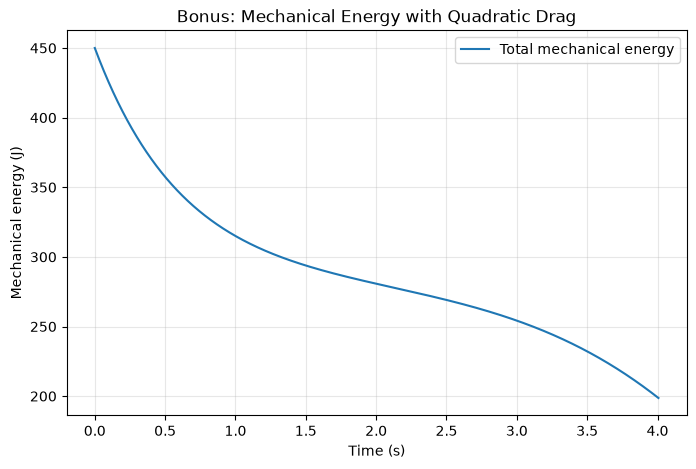

In [11]:

plt.figure(figsize=(8, 5))
plt.plot(drag["t"], drag["E"], label="Total mechanical energy")
plt.xlabel("Time (s)")
plt.ylabel("Mechanical energy (J)")
plt.title("Bonus: Mechanical Energy with Quadratic Drag")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Bonus interpretation

With air drag included, the total mechanical energy goes down during the flight instead of staying constant. I got an energy loss of about 251.34 J. The work done by drag came out to about -251.25 J, so the magnitudes differ by only about 0.03%.

This makes sense because drag is actually removing mechanical energy from the projectile. That is different from Parts A-C, where the energy change comes from numerical error.
